In [1]:
# Code for BirdCLEF 2026 competition

import librosa
import numpy as np
import pandas as pd
import os

In [2]:
# train_soundscapes_labels has the following information for each file in train_soundscapes:
# - The filename of the soundscape
# - The primary label (the bird species that is most prominently featured in the soundscape)
# - The time intervals during which the primary label is present in the soundscape

# For each broad class of animals, we classify the soundscapes that primarily feature that class.

taxonomy_df = pd.read_csv("taxonomy.csv")

# The problem with this code is that each 5 second interval should be treated as a separate data point.

train_soundscapes_labels_df = pd.read_csv("train_soundscapes_labels.csv")

# train_soundscapes_reduced_df treats every 5 second interval as a separate data point.

train_soundscapes_reduced_df = pd.DataFrame({
    "filename": train_soundscapes_labels_df.iloc[:, :3].astype(str).agg(''.join, axis=1),
    "primary_label": train_soundscapes_labels_df.iloc[:, 3]
})

In [3]:
# For each file, we list all animals that are present in the file
# We then classify the file as belonging to the class of each of those animals.

classes = ['Insecta', 'Reptilia', 'Amphibia', 'Mammalia', 'Aves']
filenames = {value: [] for value in classes}

for entry in train_soundscapes_reduced_df.itertuples():
    filename = entry.filename
    primary_label = entry.primary_label.split(';') # This records all species in a file.

    found = {value: False for value in classes}
    
    for label in primary_label:
        for value in classes:
            if taxonomy_df[taxonomy_df['primary_label'] == label]['class_name'].values[0] == value:
                found[value] = True
    
    for value in classes:
         if found[value]:
            filenames[value].append(filename)

In [4]:
# Number of files in each class
# It is troubling that only 26 of the files have reptiles.

print(f"Insecta: {len(filenames['Insecta'])}")
print(f"Reptilia: {len(filenames['Reptilia'])}")
print(f"Amphibia: {len(filenames['Amphibia'])}")
print(f"Mammalia: {len(filenames['Mammalia'])}")
print(f"Aves: {len(filenames['Aves'])}")

Insecta: 336
Reptilia: 26
Amphibia: 1132
Mammalia: 82
Aves: 424


In [5]:
# For each class, creates a list of non-elements of that class.
# We cannot include all non-elements of a class, because there are too many.
# Instead, we will make the list as long as the list of elements of that class.
# Also shuffles the elements of each class.

import random

filenames_non_elements = {value : [] for value in classes}
filenames_all = list(set().union(*filenames.values()))

# The following loop works for every class except Amphibia because that class has too many elements.
# We add 80% of the elements of each class to the training set, and 20% to the test set.
# This loop chooses random elements to add to the class because the data tends to be ordered by location.
# We also don't want too many 5 second intervals from the same 1 minute audio clip to be in the same set.

for value in ['Insecta', 'Reptilia', 'Mammalia', 'Aves']:
    length_current = 0
    length_target = len(filenames[value])
    random.shuffle(filenames[value])
    while length_current < length_target:
        filename = random.choice(filenames_all)
        if filename not in filenames[value] and filename not in filenames_non_elements[value]:
            filenames_non_elements[value].append(filename)
            length_current += 1

# This code lists all filenames which do not belong to Amphibia.

filenames_non_elements['Amphibia'] = [filename for filename in filenames_all if filename not in filenames['Amphibia']]

length = len(filenames_non_elements['Amphibia'])

# This line truncates the elements of Amphibia to be the same length as the non-elements of Amphibia.

random.shuffle(filenames['Amphibia'])
filenames['Amphibia'] = filenames['Amphibia'][:length]


In [6]:
# Creates train and test sets for each class, with an 80-20 split.
# There is also a train-test split for non-elements of each class.

filenames_train = {value: filenames[value][:int(0.8 * len(filenames[value]))] for value in classes}
filenames_test = {value: filenames[value][int(0.8 * len(filenames[value])):] for value in classes}
filenames_non_elements_train = {value: filenames_non_elements[value][:int(0.8 * len(filenames_non_elements[value]))] for value in classes}
filenames_non_elements_test = {value: filenames_non_elements[value][int(0.8 * len(filenames_non_elements[value])):] for value in classes}

In [ ]:
# The previous window justs lists the filenames for each train and test set.
# This code actually finds the audio data corresponding to each filename.

train_dfs = {value: [] for value in classes}
test_dfs = {value: [] for value in classes}
train_dfs_non_elements = {value: [] for value in classes}
test_dfs_non_elements = {value: [] for value in classes}

for value in classes:
    for filename in filenames_train[value]:
        file = filename[:-16]
        file_start = filename[-16:-8]
        file_end = filename[-8:]
        audio, sample_rate = librosa.load(f"train_soundscapes/{file}", sr=None)
        train_dfs[value].append((audio, sample_rate, file_start, file_end))
    
    for filename in filenames_test[value]:
        file = filename[:-16]
        file_start = filename[-16:-8]
        file_end = filename[-8:]
        audio, sample_rate = librosa.load(f"train_soundscapes/{file}", sr=None)
        test_dfs[value].append((audio, sample_rate, file_start, file_end))
    
    for filename in filenames_non_elements_train[value]:
        file = filename[:-16]
        file_start = filename[-16:-8]
        file_end = filename[-8:]
        audio, sample_rate = librosa.load(f"train_soundscapes/{file}", sr=None)
        train_dfs_non_elements[value].append((audio, sample_rate, file_start, file_end))
    
    for filename in filenames_non_elements_test[value]:
        file = filename[:-16]
        file_start = filename[-16:-8]
        file_end = filename[-8:]
        audio, sample_rate = librosa.load(f"train_soundscapes/{file}", sr=None)
        test_dfs_non_elements[value].append((audio, sample_rate, file_start, file_end))

In [12]:
# This code uses a logistic regression model with PCA for dimensionality reduction for each class.
# It creates a separate classifier for each class.

# As discussed in the 32526 notebook, the Aves class took much longer to process than the other classes.
# In this version, we skip that class entirely.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from time import time

models = {}
X_test_pca_dict = {}
y_test_combined_dict = {}

# Records the pca for each class.

pca = {}


for value in ['Insecta', 'Reptilia', 'Amphibia', 'Mammalia']:
    t = time()
    print(f"Processing class {value}...")
    combined_train = [(df[0], 1) for df in train_dfs[value]] + [(df[0], 0) for df in train_dfs_non_elements[value]]
    combined_test = [(df[0], 1) for df in test_dfs[value]] + [(df[0], 0) for df in test_dfs_non_elements[value]]

    X_train_combined = [audio for audio, _ in combined_train]
    X_test_combined = [audio for audio, _ in combined_test]

    y_train_combined = [label for _, label in combined_train]
    y_test_combined_dict[value] = [label for _, label in combined_test]

# StandardScaler converts all of the data to a standard Normal distribution.

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)

# PCA dramatically reduces the number of components in each graph.

    pca[value] = PCA(n_components=min(100, len(X_train_scaled)))

    X_train_pca = pca[value].fit_transform(X_train_scaled)
    X_test_pca_dict[value] = pca[value].transform(X_test_scaled)

    model = LogisticRegression(max_iter=500)
    model.fit(X_train_pca, y_train_combined)
    models[value] = model
    print(f"Time taken for class {value}: {time() - t:.2f} seconds")


Processing class Insecta...
Time taken for class Insecta: 342.37 seconds
Processing class Reptilia...
Time taken for class Reptilia: 8.51 seconds
Processing class Amphibia...
Time taken for class Amphibia: 49.23 seconds
Processing class Mammalia...
Time taken for class Mammalia: 30.13 seconds


In [13]:
# Running times for each class:
# Insecta: 311.29 seconds (336)
# Reptilia: 8.46 seconds (26)
# Amphibia: 57.43 seconds (1132)
# Mammalia: 34.66 seconds (82)

# This code evaluates the model on the test set and prints the accuracy. Perfect score!

# To run this, I would have to keep track of X_test_pca and y_test_combined for each class.

for value in ['Insecta', 'Reptilia', 'Amphibia', 'Mammalia']:
    model = models[value]
    y_pred = model.predict(X_test_pca_dict[value])
    accuracy = accuracy_score(y_test_combined_dict[value], y_pred)
    print(f"Accuracy for {value}: {accuracy:.2f}")

Accuracy for Insecta: 1.00
Accuracy for Reptilia: 1.00
Accuracy for Amphibia: 1.00
Accuracy for Mammalia: 0.97


In [ ]:
# Just for my own curiosity, I wanted to see the components.
# Except for removing the Aves class in the previous few blocks, this is the only change I made
# from the previous version of this code.
# Each row is a principal components, and each column is a feature.

pca['Insecta'].components_

array([[ 0.0007421 ,  0.00082167,  0.0006123 , ...,  0.00090983,
         0.00086103,  0.0009412 ],
       [ 0.00079503,  0.0007746 ,  0.00047792, ...,  0.0012672 ,
         0.00120354,  0.00130057],
       [ 0.00062974,  0.0006361 ,  0.00055359, ...,  0.00046298,
         0.00044179,  0.00047037],
       ...,
       [ 0.02215501, -0.02918281, -0.01082215, ..., -0.0001951 ,
        -0.00056158,  0.00061469],
       [ 0.01094486,  0.06784   ,  0.11165963, ...,  0.00101634,
         0.00029733, -0.00113173],
       [ 0.02584067,  0.09933794,  0.02533549, ...,  0.00063767,
         0.00094572,  0.00146045]], shape=(100, 1920000))

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


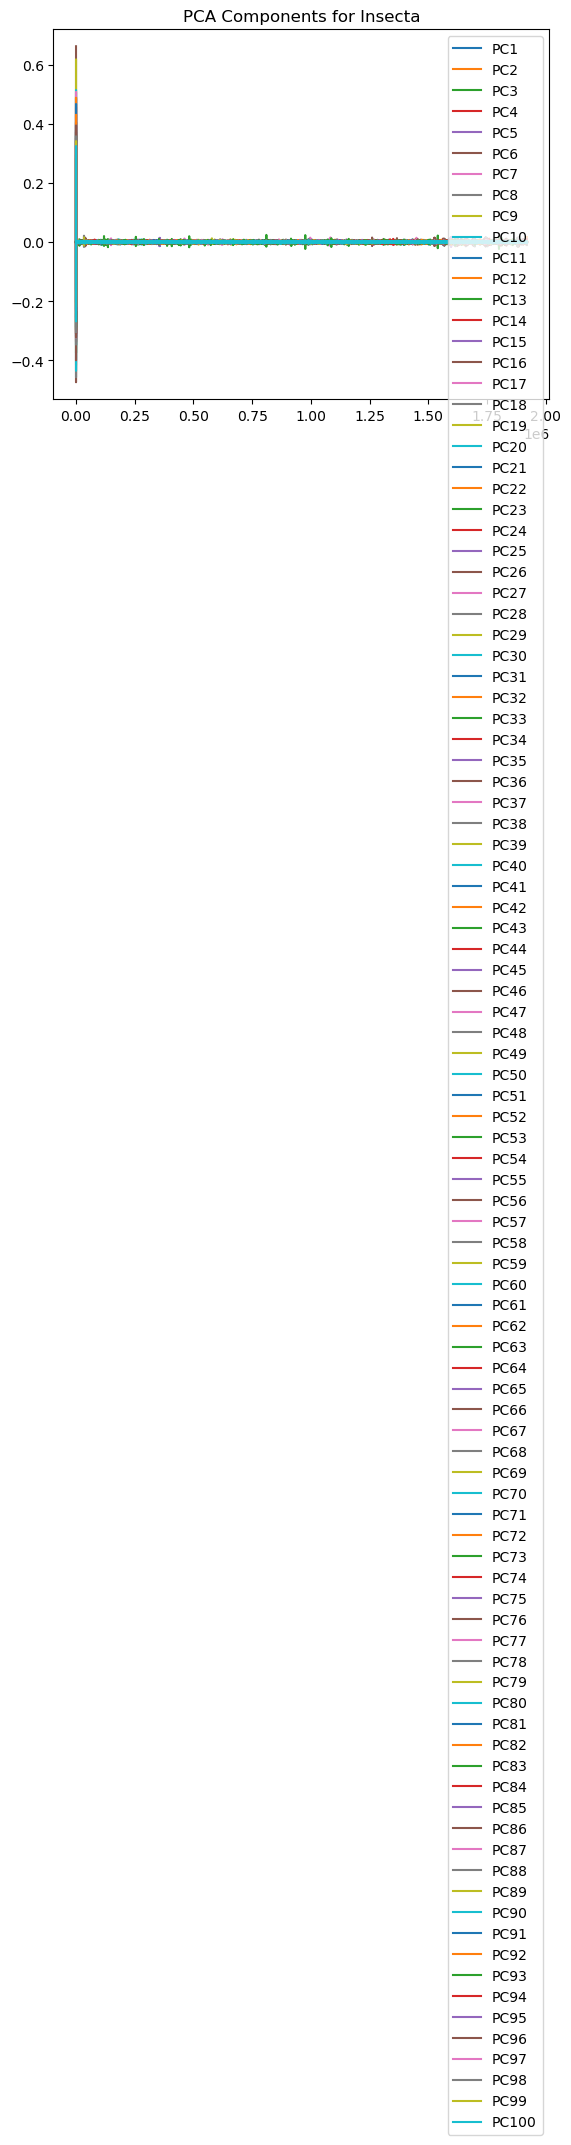

In [15]:
import matplotlib.pyplot as plt

for i, comp in enumerate(pca['Insecta'].components_):
    plt.plot(comp, label=f"PC{i+1}")
plt.legend()
plt.title("PCA Components for Insecta")
plt.show()

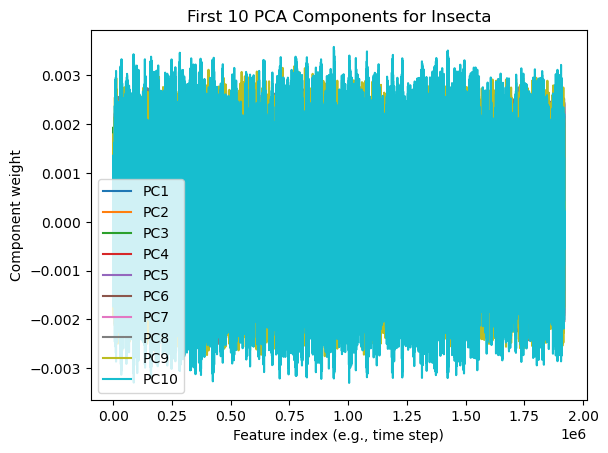

In [16]:
# A hard graph to read! Here are the first 10 principal components for Insecta.

n_to_plot = 10

for i, comp in enumerate(pca['Insecta'].components_[:n_to_plot]):
    plt.plot(comp, label=f"PC{i+1}")

plt.legend()
plt.title("First 10 PCA Components for Insecta")
plt.xlabel("Feature index (e.g., time step)")
plt.ylabel("Component weight")
plt.show()

In [ ]:
# How much of the variance each component explains for Insecta.

pca_current = pca['Insecta']
pca_current.explained_variance_ratio_

array([1.26515625e-01, 1.09199169e-01, 9.26119288e-02, 8.22759042e-02,
       7.55603848e-02, 6.87220796e-02, 5.68217714e-02, 4.96970320e-02,
       4.37516826e-02, 3.63301980e-02, 3.28502780e-02, 2.76989540e-02,
       2.51592256e-02, 2.26773526e-02, 1.75655966e-02, 1.58240256e-02,
       1.38121262e-02, 1.15568854e-02, 1.04325593e-02, 9.61825297e-03,
       9.01053191e-03, 7.83713544e-03, 6.80429080e-03, 5.47282746e-03,
       4.55154189e-03, 4.41454888e-03, 3.92623181e-03, 3.43937217e-03,
       3.22502756e-03, 2.93361207e-03, 2.37796492e-03, 2.05961250e-03,
       1.71540271e-03, 1.26609033e-03, 9.83253806e-04, 9.62382313e-04,
       9.09509348e-04, 8.51664482e-04, 7.20551694e-04, 7.07252210e-04,
       6.45446495e-04, 6.01579411e-04, 5.81267632e-04, 5.42843114e-04,
       5.10281845e-04, 4.86412296e-04, 4.58775002e-04, 4.06397401e-04,
       3.73719518e-04, 3.68672223e-04, 3.25318951e-04, 3.06066954e-04,
       2.80770946e-04, 2.73022457e-04, 2.40352631e-04, 1.98169832e-04,
      

In [18]:
pca_current.explained_variance_

array([2.43364037e+05, 2.10054297e+05, 1.78147268e+05, 1.58265007e+05,
       1.45347109e+05, 1.32193022e+05, 1.09301722e+05, 9.55966535e+04,
       8.41602460e+04, 6.98843613e+04, 6.31904263e+04, 5.32813973e+04,
       4.83960042e+04, 4.36219012e+04, 3.37889847e+04, 3.04389182e+04,
       2.65688510e+04, 2.22306952e+04, 2.00679540e+04, 1.85015636e+04,
       1.73325581e+04, 1.50754258e+04, 1.30886575e+04, 1.05274695e+04,
       8.75529494e+03, 8.49177672e+03, 7.55245548e+03, 6.61593773e+03,
       6.20362684e+03, 5.64306329e+03, 4.57422666e+03, 3.96184750e+03,
       3.29972941e+03, 2.43543715e+03, 1.89137599e+03, 1.85122782e+03,
       1.74952198e+03, 1.63825225e+03, 1.38604516e+03, 1.36046242e+03,
       1.24157364e+03, 1.15719141e+03, 1.11811990e+03, 1.04420693e+03,
       9.81572435e+02, 9.35657238e+02, 8.82494448e+02, 7.81741483e+02,
       7.18882673e+02, 7.09173754e+02, 6.25779885e+02, 5.88746961e+02,
       5.40087842e+02, 5.25182936e+02, 4.62339626e+02, 3.81197267e+02,
      

In [ ]:
# The same graph as before, but with each component plotted separately for better readability.

fig, axes = plt.subplots(5, 2, figsize=(10, 12))

for i, ax in enumerate(axes.flat):
    if i < 10:
        ax.plot(pca_current.components_[i])
        ax.set_title(f"PC{i+1}")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()